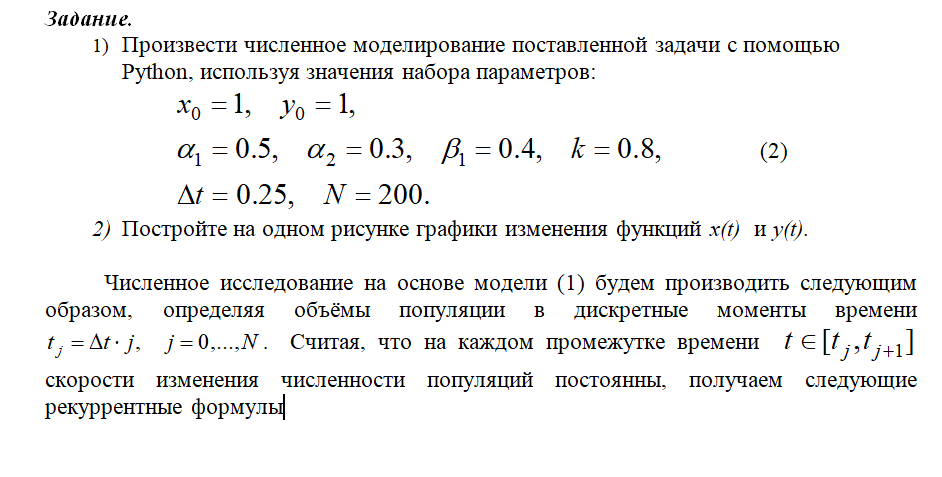

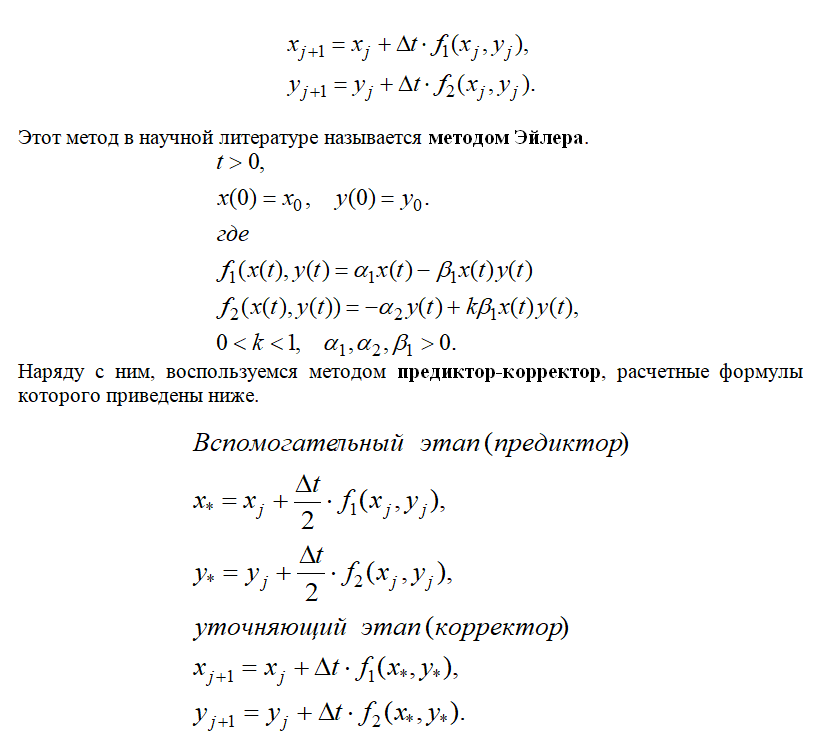

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x0, y0 = 1.0, 1.0
a1, a2 = 0.5, 0.3
b1, k  = 0.4, 0.8
dt = 0.25
N  = 200

In [5]:
def f1(x, y):  # dx/dt
    return a1*x - b1*x*y

def f2(x, y):  # dy/dt
    return -a2*y + k*b1*x*y
def euler_system(x0, y0, dt, N):
    x = np.empty(N+1, dtype=float)
    y = np.empty(N+1, dtype=float)
    x[0], y[0] = x0, y0
    for j in range(N):
        x[j+1] = x[j] + dt * f1(x[j], y[j])
        y[j+1] = y[j] + dt * f2(x[j], y[j])
    return x, y
def predictor_corrector(x0, y0, dt, N):
    x = np.empty(N+1, dtype=float)
    y = np.empty(N+1, dtype=float)
    x[0], y[0] = x0, y0
    for j in range(N):
        # предиктор
        x_star = x[j] + (dt/2.0) * f1(x[j], y[j])
        y_star = y[j] + (dt/2.0) * f2(x[j], y[j])
        # корректор
        x[j+1] = x[j] + dt * f1(x_star, y_star)
        y[j+1] = y[j] + dt * f2(x_star, y_star)
    return x, y

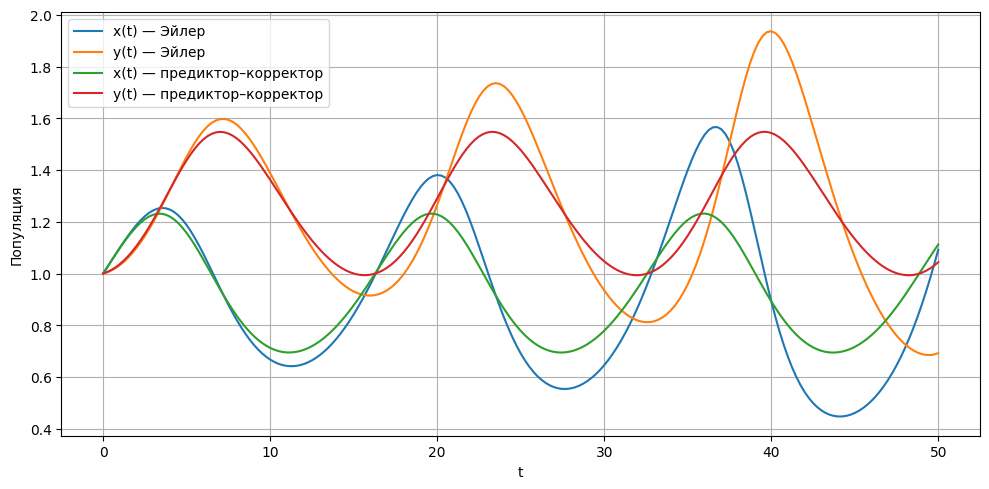

Эйлер:       x(N) = 1.0918144933786393  y(N) = 0.6923216495131412
Предикт–корр: x(N) = 1.1117577409438413  y(N) = 1.0439019206921236


In [6]:
t = np.arange(0, (N+1)*dt, dt)

x_e,  y_e  = euler_system(x0, y0, dt, N)
x_pc, y_pc = predictor_corrector(x0, y0, dt, N)

# графики на одном рисунке
plt.figure(figsize=(10,5))
plt.plot(t, x_e,  label='x(t) — Эйлер')
plt.plot(t, y_e,  label='y(t) — Эйлер')
plt.plot(t, x_pc, label='x(t) — предиктор–корректор')
plt.plot(t, y_pc, label='y(t) — предиктор–корректор')
plt.xlabel('t'); plt.ylabel('Популяция'); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

# финальные значения для контроля
print("Эйлер:       x(N) =", x_e[-1],  " y(N) =", y_e[-1])
print("Предикт–корр: x(N) =", x_pc[-1], " y(N) =", y_pc[-1])